# BERTimbau — comparação de configurações de rótulo (GoEmotions PT-BR)

## Configurações

| # | Config | Rótulos | Tipo | Filtro de linhas |
|---|--------|---------|------|------------------|
| 0 | **Referência** (baseline) | 27 + neutral (28) | multi-label | nenhum (reaproveita o treino salvo) |
| 1a | 27 · multi · *drop-all-neutral* | 27 | multi-label | remove **todo** texto com `neutral` |
| 1b | 27 · multi · *drop-only-neutral* | 27 | multi-label | remove só quem tem **somente** `neutral` |
| 2 | 27 + neutral · single | 28 | single-label | mantém só quem tem **exatamente 1** rótulo (dos 28) |
| 3 | 27 · single (**= TACO**) | 27 | single-label | exatamente 1 rótulo **e** não-`neutral` |

## Ambiente (Colab/Drive opcional)

In [1]:
USE_COLAB = False
USE_DRIVE = False

if USE_COLAB and USE_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")

## Imports e configurações globais

In [2]:
import warnings
warnings.filterwarnings("ignore")

import io, re, gzip, lzma, json, time, math, zipfile
import numpy as np
import pandas as pd
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import Optimizer

from transformers import AutoTokenizer, AutoModel, DataCollatorWithPadding

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, hamming_loss, average_precision_score,
)
from scipy.stats import wilcoxon

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

RANDOM_STATE = 42

if USE_COLAB and USE_DRIVE:
    ROOT = Path("/content/drive/MyDrive/Fuzzy_BERT")
else:
    ROOT = Path("..")

DATA_DIR  = ROOT / "data/treated"
OUT_BASE  = ROOT / "data/out"
CKPT_BASE = ROOT / "data/checkpoints"

N_OUTER_FOLDS = 5
TEXT_COL   = "CLEAN_TEXT"
MAX_LEN    = 128
BATCH_SIZE = 32
WARMUP_RATIO  = 0.1
LEARNING_RATE = 2e-5
VAL_FRACTION  = 0.10
NUM_EPOCHS    = 4                    # mesmo do BERTimbau no baseline

THRESH_GRID     = np.linspace(0.05, 0.95, 19)
FIXED_THRESHOLD = 0.5

COMPRESSION       = "xz"
SAVE_BEST_FP16    = True
PRUNE_RESUME_CKPT = True

MODEL_NAME = "neuralmind/bert-base-portuguese-cased"   # BERTimbau (único modelo)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 28 rótulos "canônicos" (ordem fixa). neutral é o último.
EMOTION_COLS_28 = [
    'admiration', 'amusement', 'anger', 'annoyance',
    'approval', 'caring', 'confusion', 'curiosity', 'desire',
    'disappointment', 'disapproval', 'disgust', 'embarrassment',
    'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love',
    'nervousness', 'optimism', 'pride', 'realization', 'relief',
    'remorse', 'sadness', 'surprise', 'neutral'
]
EMO27 = [c for c in EMOTION_COLS_28 if c != "neutral"]     # 27 emoções (sem neutral)

torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

OUT_BASE.mkdir(parents=True, exist_ok=True)
CKPT_BASE.mkdir(parents=True, exist_ok=True)

print(f"Device : {DEVICE}")
print(f"Modelo : {MODEL_NAME}")
print(f"Rótulos: 28 canônicos (27 emoções + neutral); EMO27 = {len(EMO27)}")

Device : cuda
Modelo : neuralmind/bert-base-portuguese-cased
Rótulos: 28 canônicos (27 emoções + neutral); EMO27 = 27


## Registro das 5 configurações

Cada config define **quais linhas manter** (`row_filter`) e **quais colunas de rótulo usar**
(`label_cols`). Os filtros usam sempre as 28 colunas originais para decidir; só depois o `Y` é
recortado nas colunas da config.

In [3]:
def sum28(df):
    """Nº de rótulos ativos por linha considerando as 28 colunas originais."""
    return df[EMOTION_COLS_28].sum(axis=1).values

# --- filtros de linha (recebem df com as 28 colunas, retornam df filtrado) ---
def f_none(df):
    return df

def f_drop_all_neutral(df):                       # 1a: remove todo texto com neutral
    return df[df["neutral"] == 0].reset_index(drop=True)

def f_drop_only_neutral(df):                      # 1b: remove só quem tem SOMENTE neutral
    only_neutral = (df["neutral"] == 1) & (sum28(df) == 1)
    return df[~only_neutral].reset_index(drop=True)

def f_single_28(df):                              # 2: exatamente 1 rótulo entre os 28
    return df[sum28(df) == 1].reset_index(drop=True)

def f_single_27_no_neutral(df):                   # 3: exatamente 1 rótulo E não-neutral (= TACO)
    keep = (sum28(df) == 1) & (df["neutral"] == 0)
    return df[keep].reset_index(drop=True)

CONFIGS = {
    "ref_28_multi": {
        "display": "0 · 28 multi (ref)", "label_cols": EMOTION_COLS_28, "mode": "multi",
        "row_filter": f_none, "reuse_ref": True,
    },
    "27_multi_dropAll": {
        "display": "1a · 27 multi (drop-all-neutral)", "label_cols": EMO27, "mode": "multi",
        "row_filter": f_drop_all_neutral, "reuse_ref": False,
    },
    "27_multi_dropOnly": {
        "display": "1b · 27 multi (drop-only-neutral)", "label_cols": EMO27, "mode": "multi",
        "row_filter": f_drop_only_neutral, "reuse_ref": False,
    },
    "28_single": {
        "display": "2 · 28 single", "label_cols": EMOTION_COLS_28, "mode": "single",
        "row_filter": f_single_28, "reuse_ref": False,
    },
    "27_single": {
        "display": "3 · 27 single (TACO)", "label_cols": EMO27, "mode": "single",
        "row_filter": f_single_27_no_neutral, "reuse_ref": False,
    },
}

# diretórios de saída/checkpoint por config
for key, cfg in CONFIGS.items():
    cfg["out_dir"]  = OUT_BASE  / "bert_configs" / key
    cfg["ckpt_dir"] = CKPT_BASE / "bert_configs" / key
    cfg["out_dir"].mkdir(parents=True, exist_ok=True)
    cfg["ckpt_dir"].mkdir(parents=True, exist_ok=True)
    (cfg["out_dir"] / "cache").mkdir(parents=True, exist_ok=True)
    cfg["n_labels"] = len(cfg["label_cols"])

print("Configurações:")
for key, cfg in CONFIGS.items():
    print(f"  {key:20s} -> {cfg['display']:34s} | {cfg['n_labels']} rótulos | {cfg['mode']}")

Configurações:
  ref_28_multi         -> 0 · 28 multi (ref)                 | 28 rótulos | multi
  27_multi_dropAll     -> 1a · 27 multi (drop-all-neutral)   | 27 rótulos | multi
  27_multi_dropOnly    -> 1b · 27 multi (drop-only-neutral)  | 27 rótulos | multi
  28_single            -> 2 · 28 single                      | 28 rótulos | single
  27_single            -> 3 · 27 single (TACO)               | 27 rótulos | single


## Carregamento dos folds (28 colunas brutas) e prévia dos filtros

In [4]:
def load_fold(fold_id: int):
    return pd.read_parquet(DATA_DIR / f"fold_{fold_id}" / "data.parquet")

folds_raw = {}
for k in range(1, N_OUTER_FOLDS + 1):
    df = load_fold(k)
    missing = [c for c in EMOTION_COLS_28 if c not in df.columns]
    assert not missing, f"Fold {k} sem colunas: {missing}"
    folds_raw[k] = df
    print(f"Fold {k}: {df.shape[0]:>6} amostras (brutas)")

# prévia do tamanho de cada config (soma dos 5 folds) — só para conferência
print("\nTamanho por configuração (total nos 5 folds):")
total_raw = sum(len(folds_raw[k]) for k in folds_raw)
for key, cfg in CONFIGS.items():
    n = sum(len(cfg["row_filter"](folds_raw[k])) for k in folds_raw)
    print(f"  {cfg['display']:34s}: {n:>6} amostras  ({100*n/total_raw:5.1f}% do total)")

Fold 1:  10831 amostras (brutas)
Fold 2:  10810 amostras (brutas)
Fold 3:  10836 amostras (brutas)
Fold 4:  10909 amostras (brutas)
Fold 5:  10848 amostras (brutas)

Tamanho por configuração (total nos 5 folds):
  0 · 28 multi (ref)                :  54234 amostras  (100.0% do total)
  1a · 27 multi (drop-all-neutral)  :  36485 amostras  ( 67.3% do total)
  1b · 27 multi (drop-only-neutral) :  38235 amostras  ( 70.5% do total)
  2 · 28 single                     :  45418 amostras  ( 83.7% do total)
  3 · 27 single (TACO)              :  29419 amostras  ( 54.2% do total)


## Dataset e DataLoader (parametrizados pelas colunas da config)

In [5]:
class EmotionDataset(Dataset):
    def __init__(self, df, tokenizer, label_cols, max_len=MAX_LEN):
        self.texts = df[TEXT_COL].fillna("").astype(str).tolist()
        self.labels = df[label_cols].values.astype(np.float32)
        self.tokenizer = tokenizer
        self.max_len = max_len
    def __len__(self):
        return len(self.texts)
    def __getitem__(self, idx):
        enc = self.tokenizer(self.texts[idx], max_length=self.max_len, truncation=True)
        enc["labels"] = self.labels[idx].tolist()
        return enc

def make_loaders(df_train, df_eval, tokenizer, label_cols, shuffle_train=True):
    collator = DataCollatorWithPadding(tokenizer, padding="longest", return_tensors="pt")
    ds_tr = EmotionDataset(df_train, tokenizer, label_cols)
    ds_ev = EmotionDataset(df_eval,  tokenizer, label_cols)
    lt = DataLoader(ds_tr, batch_size=BATCH_SIZE, shuffle=shuffle_train,
                    num_workers=0, pin_memory=True, collate_fn=collator)
    le = DataLoader(ds_ev, batch_size=BATCH_SIZE, shuffle=False,
                    num_workers=0, pin_memory=True, collate_fn=collator)
    return lt, le

def split_train_val(df_trainfull, val_fraction=VAL_FRACTION, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed)
    n = len(df_trainfull); perm = rng.permutation(n)
    n_val = max(1, int(round(n * val_fraction)))
    df_val = df_trainfull.iloc[perm[:n_val]].reset_index(drop=True)
    df_tr  = df_trainfull.iloc[perm[n_val:]].reset_index(drop=True)
    return df_tr, df_val

print("Dataset e loaders prontos.")

Dataset e loaders prontos.


## Modelo — BERTimbau + cabeça multi-label (idêntico ao baseline, n_labels variável)

In [6]:
class TransformerForEmotions(nn.Module):
    def __init__(self, model_name, n_labels, dropout=0.1):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name, torch_dtype=torch.float32)
        hidden = self.bert.config.hidden_size
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden, n_labels)
    def forward(self, input_ids, attention_mask):
        out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls = out.last_hidden_state[:, 0, :]
        return self.classifier(self.dropout(cls))

def build_model(n_labels):
    return TransformerForEmotions(MODEL_NAME, n_labels).to(DEVICE)

print("Classe do modelo definida.")

Classe do modelo definida.


## Class-Balanced Loss (idêntica ao baseline)

In [7]:
class CrossBalancedLoss(nn.Module):
    def __init__(self, samples_per_class, beta=0.9999):
        super().__init__()
        eff = 1.0 - np.power(beta, samples_per_class)
        w = (1.0 - beta) / np.where(eff == 0, 1e-8, eff)
        w = w / w.sum() * len(samples_per_class)
        self.register_buffer("weights", torch.tensor(w, dtype=torch.float32))
    def forward(self, logits, targets):
        bce = nn.functional.binary_cross_entropy_with_logits(logits, targets, reduction="none")
        return (bce * self.weights.unsqueeze(0)).mean()

def compute_samples_per_class(df, label_cols):
    counts = np.array([int(df[c].sum()) for c in label_cols], dtype=np.float64)
    return np.maximum(counts, 1)

print("CrossBalancedLoss definida.")

CrossBalancedLoss definida.


## Otimizador (AdamWeightDecay fiel ao BERT) e scheduler (idênticos ao baseline)

In [8]:
class AdamWeightDecayOptimizer(Optimizer):
    def __init__(self, params, lr=2e-5, weight_decay_rate=0.01,
                 beta_1=0.9, beta_2=0.999, epsilon=1e-6, exclude_from_weight_decay=None):
        if exclude_from_weight_decay is None:
            exclude_from_weight_decay = ["LayerNorm", "layer_norm", "bias"]
        defaults = dict(lr=lr, weight_decay_rate=weight_decay_rate, beta_1=beta_1,
                        beta_2=beta_2, epsilon=epsilon,
                        exclude_from_weight_decay=exclude_from_weight_decay)
        super().__init__(params, defaults)
    def _use_wd(self, name, exclude):
        return not any(re.search(p, name) for p in exclude)
    @torch.no_grad()
    def step(self, closure=None):
        loss = closure() if closure is not None else None
        for g in self.param_groups:
            b1, b2, eps = g["beta_1"], g["beta_2"], g["epsilon"]
            wd, lr = g["weight_decay_rate"], g["lr"]
            exclude = g["exclude_from_weight_decay"]; names = g.get("_param_names", {})
            for p in g["params"]:
                if p.grad is None: continue
                grad = p.grad.data; st = self.state[p]
                if len(st) == 0:
                    st["m"] = torch.zeros_like(p.data); st["v"] = torch.zeros_like(p.data); st["step"]=0
                m, v = st["m"], st["v"]; st["step"] += 1
                nm = b1*m + (1.0-b1)*grad
                nv = b2*v + (1.0-b2)*grad.pow(2)
                upd = nm / (nv.sqrt() + eps)
                if wd > 0 and self._use_wd(names.get(id(p), ""), exclude):
                    upd = upd + wd * p.data
                p.data.add_(upd, alpha=-lr); st["m"].copy_(nm); st["v"].copy_(nv)
        return loss

def _param_groups(model, exclude=("LayerNorm","layer_norm","bias")):
    decay, no_decay, names = [], [], {}
    for n, p in model.named_parameters():
        if not p.requires_grad: continue
        names[id(p)] = n
        (no_decay if any(re.search(e, n) for e in exclude) else decay).append(p)
    return decay, no_decay, names

def build_optimizer(model, lr=LEARNING_RATE):
    decay, no_decay, names = _param_groups(model)
    groups = [{"params": decay, "weight_decay_rate": 0.01},
              {"params": no_decay, "weight_decay_rate": 0.0}]
    opt = AdamWeightDecayOptimizer(groups, lr=lr, weight_decay_rate=0.01,
                                   beta_1=0.9, beta_2=0.999, epsilon=1e-6)
    for gp in opt.param_groups:
        gp["_param_names"] = names
    return opt

def build_scheduler(optimizer, num_steps, warmup_ratio=WARMUP_RATIO):
    from torch.optim.lr_scheduler import LambdaLR
    nw = int(num_steps * warmup_ratio)
    def lr_lambda(step):
        if step < nw: return float(step)/float(max(1, nw))
        prog = float(step-nw)/float(max(1, num_steps-nw))
        return max(0.0, 1.0-prog)
    return LambdaLR(optimizer, lr_lambda)

print("Otimizador e scheduler prontos.")

Otimizador e scheduler prontos.


## Checkpoints compactados + treino/avaliação + métricas (idênticos ao baseline)

In [9]:
def _compress(raw):
    if COMPRESSION=="gzip": return gzip.compress(raw, 6)
    if COMPRESSION=="xz":   return lzma.compress(raw, preset=6)
    if COMPRESSION=="zip":
        buf=io.BytesIO()
        with zipfile.ZipFile(buf,"w",zipfile.ZIP_DEFLATED,compresslevel=6) as z: z.writestr("ckpt.pt", raw)
        return buf.getvalue()
    raise ValueError(COMPRESSION)

def _decompress(data):
    if data[:2]==b"\x1f\x8b": return gzip.decompress(data)
    if data[:6]==b"\xfd7zXZ\x00": return lzma.decompress(data)
    if data[:2]==b"PK":
        with zipfile.ZipFile(io.BytesIO(data)) as z: return z.read(z.namelist()[0])
    return data

def torch_save_compressed(payload, path):
    buf=io.BytesIO(); torch.save(payload, buf); Path(path).write_bytes(_compress(buf.getvalue()))

def torch_load_compressed(path, map_location=None, weights_only=False):
    import numpy.dtypes
    torch.serialization.add_safe_globals([numpy.dtypes.Float64DType])
    raw=_decompress(Path(path).read_bytes())
    return torch.load(io.BytesIO(raw), map_location=map_location, weights_only=weights_only)

def save_resume_ckpt(model, opt, sch, epoch, fold, ckpt_dir):
    torch_save_compressed({"epoch":epoch,"fold":fold,"model_state_dict":model.state_dict(),
        "optimizer_state_dict":opt.state_dict(),"scheduler_state_dict":sch.state_dict()},
        Path(ckpt_dir)/f"fold_{fold}_last.ptz")

def save_best_ckpt(model, epoch, fold, val_metrics, ckpt_dir):
    sd=model.state_dict()
    if SAVE_BEST_FP16: sd={k:(v.half() if v.is_floating_point() else v) for k,v in sd.items()}
    torch_save_compressed({"epoch":epoch,"fold":fold,"val_metrics":val_metrics,
        "model_state_dict":sd,"fp16":SAVE_BEST_FP16}, Path(ckpt_dir)/f"fold_{fold}_best.ptz")

def load_model_weights(model, ckpt_path):
    ck=torch_load_compressed(ckpt_path, map_location=DEVICE)
    model.load_state_dict(ck["model_state_dict"]); return ck

def train_one_epoch(model, loader, opt, sch, criterion, device):
    model.train(); total=0.0
    for batch in loader:
        ids=batch["input_ids"].to(device); am=batch["attention_mask"].to(device)
        y=batch["labels"].to(device)
        opt.zero_grad()
        logits=model(input_ids=ids, attention_mask=am)
        loss=criterion(logits, y); loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step(); sch.step(); total+=loss.item()
    return total/max(len(loader),1)

@torch.no_grad()
def infer_proba(model, loader, device):
    model.eval(); L=[]; Y=[]
    for batch in loader:
        ids=batch["input_ids"].to(device); am=batch["attention_mask"].to(device)
        L.append(model(input_ids=ids, attention_mask=am).detach().cpu())
        Y.append(batch["labels"])
    L=torch.cat(L); Y=torch.cat(Y)
    return torch.sigmoid(L).numpy(), Y.numpy().astype(int)

def compute_metrics(Y_true, Y_pred, Y_proba, label_names):
    m = {
        "accuracy":        accuracy_score(Y_true, Y_pred),
        "hamming_loss":    hamming_loss(Y_true, Y_pred),
        "f1_macro":        f1_score(Y_true, Y_pred, average="macro",    zero_division=0),
        "f1_micro":        f1_score(Y_true, Y_pred, average="micro",    zero_division=0),
        "f1_weighted":     f1_score(Y_true, Y_pred, average="weighted", zero_division=0),
        "precision_macro": precision_score(Y_true, Y_pred, average="macro", zero_division=0),
        "recall_macro":    recall_score(Y_true, Y_pred, average="macro",    zero_division=0),
    }
    valid=[j for j in range(Y_true.shape[1]) if Y_true[:, j].sum()>0]
    if valid:
        m["roc_auc_macro"]=roc_auc_score(Y_true[:,valid], Y_proba[:,valid], average="macro")
        m["avg_precision_macro"]=average_precision_score(Y_true[:,valid], Y_proba[:,valid], average="macro")
    else:
        m["roc_auc_macro"]=m["avg_precision_macro"]=float("nan")
    m["f1_per_label"]=dict(zip(label_names, f1_score(Y_true, Y_pred, average=None, zero_division=0)))
    return m

print("Checkpoints + treino/avaliação + métricas prontos.")

Checkpoints + treino/avaliação + métricas prontos.


## Treino + probabilidades OOF por configuração (CV aninhada, com *resume*)

Mesma estratégia anti-vazamento do baseline. A cada *fold* externo `k`: filtra os *folds* pela
config, treina nos demais (validação interna para escolher a época) e gera o OOF no *fold* `k`
(também filtrado). A **config 0** reaproveita o OOF salvo pelo `baseline_BERT`.

In [10]:
def oof_path(cfg, k):
    return cfg["out_dir"] / "cache" / f"P_{cfg['out_dir'].name}_fold{k}.npy"

def history_path(cfg, k):
    return cfg["ckpt_dir"] / f"fold_{k}_history.json"

def _legacy_ref_oof(cfg, k):
    """Config 0 reaproveita o OOF (28 col) do baseline_BERT, se existir."""
    if not cfg.get("reuse_ref"): return None
    cand = OUT_BASE / "bertimbau" / "cache" / f"P_bertimbau_fold{k}.npy"
    return cand if cand.exists() else None

def make_config_folds(cfg):
    """Aplica o row_filter da config a cada fold e prepara Y (nas colunas da config)."""
    dfs, Ys = {}, {}
    for k in range(1, N_OUTER_FOLDS + 1):
        d = cfg["row_filter"](folds_raw[k])
        dfs[k] = d
        Ys[k]  = d[cfg["label_cols"]].values.astype(int)
    return dfs, Ys

def train_fold(cfg, k, tokenizer, dfs):
    op = oof_path(cfg, k)
    if op.exists():
        print(f"    [cache] OOF do fold {k} já existe."); return np.load(op)
    legacy = _legacy_ref_oof(cfg, k)
    if legacy is not None:
        print(f"    [cache] reaproveitando OOF do baseline: {legacy.name}")
        P = np.load(legacy); np.save(op, P); return P

    label_cols = cfg["label_cols"]; ckpt_dir = cfg["ckpt_dir"]
    df_test = dfs[k]
    df_trainfull = pd.concat([dfs[j] for j in range(1, N_OUTER_FOLDS+1) if j != k], ignore_index=True)
    df_tr, df_val = split_train_val(df_trainfull)

    loader_train, _ = make_loaders(df_tr, df_val, tokenizer, label_cols, shuffle_train=True)
    _, loader_val   = make_loaders(df_tr, df_val, tokenizer, label_cols, shuffle_train=False)
    _, loader_test  = make_loaders(df_tr, df_test, tokenizer, label_cols, shuffle_train=False)

    criterion = CrossBalancedLoss(compute_samples_per_class(df_tr, label_cols), beta=0.9999).to(DEVICE)
    model = build_model(cfg["n_labels"])
    num_steps = len(loader_train) * NUM_EPOCHS
    opt = build_optimizer(model); sch = build_scheduler(opt, num_steps)

    history = json.loads(history_path(cfg, k).read_text()) if history_path(cfg, k).exists() else []
    best_val = max([h["val_f1_macro"] for h in history], default=-1.0)

    start_epoch = 1
    last_ckpt = ckpt_dir / f"fold_{k}_last.ptz"
    if last_ckpt.exists():
        ck = torch_load_compressed(last_ckpt, map_location=DEVICE)
        model.load_state_dict(ck["model_state_dict"]); opt.load_state_dict(ck["optimizer_state_dict"])
        sch.load_state_dict(ck["scheduler_state_dict"]); start_epoch = ck["epoch"] + 1
        print(f"    retomando fold {k} da época {start_epoch}")

    for epoch in range(start_epoch, NUM_EPOCHS + 1):
        t0 = time.time()
        tr_loss = train_one_epoch(model, loader_train, opt, sch, criterion, DEVICE)
        vp, vt = infer_proba(model, loader_val, DEVICE)
        vf1 = f1_score(vt, (vp >= FIXED_THRESHOLD).astype(int), average="macro", zero_division=0)
        history.append({"epoch":epoch, "val_f1_macro":float(vf1), "train_loss":float(tr_loss)})
        history_path(cfg, k).write_text(json.dumps(history, ensure_ascii=False, indent=1))
        save_resume_ckpt(model, opt, sch, epoch, k, ckpt_dir)
        improved = vf1 > best_val
        if improved:
            best_val = vf1; save_best_ckpt(model, epoch, k, {"val_f1_macro":vf1}, ckpt_dir)
        print(f"    época {epoch}/{NUM_EPOCHS} | train_loss={tr_loss:.4f} | "
              f"val_f1={vf1:.4f}{' *' if improved else ''} | {time.time()-t0:.0f}s")

    load_model_weights(model, ckpt_dir / f"fold_{k}_best.ptz")
    P_test, _ = infer_proba(model, loader_test, DEVICE)
    np.save(op, P_test)
    if PRUNE_RESUME_CKPT and last_ckpt.exists(): last_ckpt.unlink()
    del model, opt, sch, criterion
    if DEVICE.type == "cuda": torch.cuda.empty_cache()
    return P_test

def run_config(cfg):
    print(f"\n{'='*70}\n  CONFIG: {cfg['display']}  |  {cfg['n_labels']} rótulos  |  {cfg['mode']}\n{'='*70}")
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    dfs, Ys = make_config_folds(cfg)
    P = {}
    for k in range(1, N_OUTER_FOLDS + 1):
        print(f"  Fold {k}/{N_OUTER_FOLDS}  (teste: {len(dfs[k])} amostras)")
        P[k] = train_fold(cfg, k, tokenizer, dfs)
    return {"P": P, "Y": Ys, "dfs": dfs}

# ---- roda todas as configs (comece pela 0; as demais re-treinam) ----
RESULTS = {}
for key, cfg in CONFIGS.items():
    RESULTS[key] = run_config(cfg)

print("\n✓ OOF pronto para todas as configs:", list(RESULTS))


  CONFIG: 0 · 28 multi (ref)  |  28 rótulos  |  multi


  Fold 1/5  (teste: 10831 amostras)
    [cache] OOF do fold 1 já existe.
  Fold 2/5  (teste: 10810 amostras)
    [cache] OOF do fold 2 já existe.
  Fold 3/5  (teste: 10836 amostras)
    [cache] OOF do fold 3 já existe.
  Fold 4/5  (teste: 10909 amostras)
    [cache] OOF do fold 4 já existe.
  Fold 5/5  (teste: 10848 amostras)
    [cache] OOF do fold 5 já existe.

  CONFIG: 1a · 27 multi (drop-all-neutral)  |  27 rótulos  |  multi
  Fold 1/5  (teste: 7281 amostras)
    [cache] OOF do fold 1 já existe.
  Fold 2/5  (teste: 7260 amostras)
    [cache] OOF do fold 2 já existe.
  Fold 3/5  (teste: 7286 amostras)
    [cache] OOF do fold 3 já existe.
  Fold 4/5  (teste: 7360 amostras)
    [cache] OOF do fold 4 já existe.
  Fold 5/5  (teste: 7298 amostras)
    [cache] OOF do fold 5 já existe.

  CONFIG: 1b · 27 multi (drop-only-neutral)  |  27 rótulos  |  multi
  Fold 1/5  (teste: 7614 amostras)
    [cache] OOF do fold 1 já existe.
  Fold 2/5  (teste: 7652 amostras)
    [cache] OOF do fold 2 já 

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 45212.42it/s]
[transformers] BertModel LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


    época 1/4 | train_loss=0.0929 | val_f1=0.0000 * | 542s
    época 2/4 | train_loss=0.0481 | val_f1=0.1227 * | 543s
    época 3/4 | train_loss=0.0380 | val_f1=0.3103 * | 540s
    época 4/4 | train_loss=0.0331 | val_f1=0.3411 * | 541s
  Fold 2/5  (teste: 5848 amostras)


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 31805.30it/s]
[transformers] BertModel LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

    época 1/4 | train_loss=0.0899 | val_f1=0.0000 * | 548s
    época 2/4 | train_loss=0.0461 | val_f1=0.1222 * | 545s
    época 3/4 | train_loss=0.0365 | val_f1=0.2834 * | 546s
    época 4/4 | train_loss=0.0318 | val_f1=0.3297 * | 546s
  Fold 4/5  (teste: 5989 amostras)


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 30218.55it/s]
[transformers] BertModel LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


    época 1/4 | train_loss=0.0930 | val_f1=0.0000 * | 548s
    época 2/4 | train_loss=0.0498 | val_f1=0.1720 * | 545s
    época 3/4 | train_loss=0.0395 | val_f1=0.3204 * | 546s
    época 4/4 | train_loss=0.0346 | val_f1=0.3354 * | 546s
  Fold 5/5  (teste: 5888 amostras)


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 30281.04it/s]
[transformers] BertModel LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


    época 1/4 | train_loss=0.0918 | val_f1=0.0000 * | 543s
    época 2/4 | train_loss=0.0462 | val_f1=0.1581 * | 543s
    época 3/4 | train_loss=0.0368 | val_f1=0.3066 * | 543s
    época 4/4 | train_loss=0.0323 | val_f1=0.3358 * | 545s

✓ OOF pronto para todas as configs: ['ref_28_multi', '27_multi_dropAll', '27_multi_dropOnly', '28_single', '27_single']


## Calibração de limiar por config (@0.5 e @limiar) e métricas finas

In [11]:
def calibrate_thresholds(P_cal, Y_cal, grid, n_labels):
    thr = np.full(n_labels, FIXED_THRESHOLD)
    for j in range(n_labels):
        y = Y_cal[:, j]
        if y.sum() == 0: continue
        pred = P_cal[:, j][:, None] >= grid[None, :]
        yb = (y == 1)[:, None]
        tp = (pred & yb).sum(0); fp = (pred & ~yb).sum(0); fn = (~pred & yb).sum(0)
        f1 = 2*tp / np.maximum(2*tp + fp + fn, 1e-12)
        thr[j] = float(grid[int(np.argmax(f1))])
    return thr

def metrics_at(Y_true, P_score, thr_vec, label_cols):
    Y_pred = (P_score >= thr_vec[None, :]).astype(int)
    return compute_metrics(Y_true, Y_pred, P_score, label_cols)

def singlelabel_argmax_f1(Y_true, P_score, label_cols):
    """Métrica secundária p/ configs single-label: 1 predição (argmax) por texto."""
    y_true_idx = Y_true.argmax(axis=1)                 # rótulo verdadeiro (linha tem 1 só)
    y_pred_idx = P_score.argmax(axis=1)
    return f1_score(y_true_idx, y_pred_idx, average="macro",
                    labels=list(range(len(label_cols))), zero_division=0)

# guarda métricas por config: lista de dicts por fold (fixed e tuned)
config_fold_metrics = {key: {"fixed": [], "tuned": []} for key in CONFIGS}
thresholds_store   = {key: {} for key in CONFIGS}

for key, cfg in CONFIGS.items():
    P = RESULTS[key]["P"]; Y = RESULTS[key]["Y"]; label_cols = cfg["label_cols"]
    nlab = cfg["n_labels"]; is_single = cfg["mode"] == "single"
    for k in range(1, N_OUTER_FOLDS + 1):
        train_ks = [j for j in range(1, N_OUTER_FOLDS+1) if j != k]
        P_cal = np.vstack([P[j] for j in train_ks]); Y_cal = np.vstack([Y[j] for j in train_ks])
        thr = calibrate_thresholds(P_cal, Y_cal, THRESH_GRID, nlab)
        thresholds_store[key][k] = thr

        m_fix = metrics_at(Y[k], P[k], np.full(nlab, FIXED_THRESHOLD), label_cols)
        m_tun = metrics_at(Y[k], P[k], thr, label_cols)
        if is_single:
            m_fix["f1_macro_argmax"] = singlelabel_argmax_f1(Y[k], P[k], label_cols)
            m_tun["f1_macro_argmax"] = m_fix["f1_macro_argmax"]
        else:
            m_fix["f1_macro_argmax"] = float("nan"); m_tun["f1_macro_argmax"] = float("nan")
        m_fix["outer_fold"] = k; m_tun["outer_fold"] = k
        config_fold_metrics[key]["fixed"].append(m_fix)
        config_fold_metrics[key]["tuned"].append(m_tun)
    tmean = np.mean([thresholds_store[key][k].mean() for k in range(1, N_OUTER_FOLDS+1)])
    print(f"{cfg['display']:34s} | limiar médio calibrado = {tmean:.3f}")

print("\n✓ Métricas finas calculadas para as 5 configs.")

0 · 28 multi (ref)                 | limiar médio calibrado = 0.245
1a · 27 multi (drop-all-neutral)   | limiar médio calibrado = 0.269
1b · 27 multi (drop-only-neutral)  | limiar médio calibrado = 0.272
2 · 28 single                      | limiar médio calibrado = 0.244
3 · 27 single (TACO)               | limiar médio calibrado = 0.246

✓ Métricas finas calculadas para as 5 configs.


## Agrupamentos — Ekman (6 grupos) e Sentimento (3 grupos)

Ambos derivados das **27 emoções** (mapeamentos oficiais do GoEmotions; `neutral` **fora** do
agrupamento). Para tornar as configs comparáveis no nível grosso, a avaliação agrupada usa **só
instâncias com ≥1 das 27 emoções** (linhas puramente `neutral` são descartadas) e o **mesmo** espaço
de grupos em todas as configs. Uma instância pertence a um grupo se **qualquer** emoção-membro estiver
ativa (operação OR), como na simulação de fusão do baseline.

In [12]:
EKMAN_MAP = {
    "anger":    ["anger", "annoyance", "disapproval"],
    "disgust":  ["disgust"],
    "fear":     ["fear", "nervousness"],
    "joy":      ["admiration", "amusement", "approval", "caring", "desire", "excitement",
                 "gratitude", "joy", "love", "optimism", "pride", "relief"],
    "sadness":  ["sadness", "disappointment", "embarrassment", "grief", "remorse"],
    "surprise": ["surprise", "realization", "confusion", "curiosity"],
}
SENTIMENT_MAP = {
    "positive":  ["admiration", "amusement", "approval", "caring", "desire", "excitement",
                  "gratitude", "joy", "love", "optimism", "pride", "relief"],
    "negative":  ["anger", "annoyance", "disappointment", "disapproval", "disgust",
                  "embarrassment", "fear", "grief", "nervousness", "remorse", "sadness"],
    "ambiguous": ["confusion", "curiosity", "realization", "surprise"],
}
# checagens de cobertura (as 27 emoções aparecem exatamente uma vez em cada mapa)
assert sorted(sum(EKMAN_MAP.values(), [])) == sorted(EMO27)
assert sorted(sum(SENTIMENT_MAP.values(), [])) == sorted(EMO27)

def grouped_from_binary(Y_bin, label_cols, group_map):
    """OR das colunas-membro por grupo. Restringe a linhas com >=1 emoção (das 27) ativa.
       Retorna (G, mask_rows): G (n_rows_keep, n_groups) e a máscara aplicada."""
    col_idx = {c: i for i, c in enumerate(label_cols)}
    emo_idx = [col_idx[c] for c in EMO27 if c in col_idx]          # emoções presentes na config
    keep = Y_bin[:, emo_idx].sum(axis=1) > 0 if emo_idx else np.zeros(len(Y_bin), bool)
    groups = list(group_map.keys())
    G = np.zeros((keep.sum(), len(groups)), dtype=int)
    Yk = Y_bin[keep]
    for gi, g in enumerate(groups):
        idx = [col_idx[c] for c in group_map[g] if c in col_idx]
        if idx:
            G[:, gi] = (Yk[:, idx].sum(axis=1) > 0).astype(int)
    return G, keep, groups

def grouped_macro_f1(Y_true, Y_pred, label_cols, group_map):
    Gt, keep, groups = grouped_from_binary(Y_true, label_cols, group_map)
    Gp = np.zeros_like(Gt)
    col_idx = {c: i for i, c in enumerate(label_cols)}
    Ypk = Y_pred[keep]
    for gi, g in enumerate(groups):
        idx = [col_idx[c] for c in group_map[g] if c in col_idx]
        if idx:
            Gp[:, gi] = (Ypk[:, idx].sum(axis=1) > 0).astype(int)
    per = f1_score(Gt, Gp, average=None, zero_division=0)
    macro = f1_score(Gt, Gp, average="macro", zero_division=0)
    return macro, dict(zip(groups, per))

print("Mapas de Ekman (6) e Sentimento (3) prontos; cobertura das 27 emoções conferida.")

Mapas de Ekman (6) e Sentimento (3) prontos; cobertura das 27 emoções conferida.


## Métricas agrupadas por config (Ekman e Sentimento, no melhor limiar)

In [13]:
grouped_fold = {key: {"ekman": [], "sentiment": []} for key in CONFIGS}

for key, cfg in CONFIGS.items():
    P = RESULTS[key]["P"]; Y = RESULTS[key]["Y"]; label_cols = cfg["label_cols"]
    for k in range(1, N_OUTER_FOLDS + 1):
        thr = thresholds_store[key][k]
        Y_pred = (P[k] >= thr[None, :]).astype(int)
        ek_macro, ek_per = grouped_macro_f1(Y[k], Y_pred, label_cols, EKMAN_MAP)
        se_macro, se_per = grouped_macro_f1(Y[k], Y_pred, label_cols, SENTIMENT_MAP)
        grouped_fold[key]["ekman"].append({"macro": ek_macro, **ek_per, "outer_fold": k})
        grouped_fold[key]["sentiment"].append({"macro": se_macro, **se_per, "outer_fold": k})

print("✓ Métricas agrupadas (Ekman/Sentimento) calculadas para as 5 configs.")

✓ Métricas agrupadas (Ekman/Sentimento) calculadas para as 5 configs.


## Comparação final — Macro-F1 (fino, Ekman, Sentimento)

In [14]:
def mean_std(vals):
    v = np.array(vals, dtype=float)
    return f"{np.nanmean(v):.4f} ± {np.nanstd(v):.4f}"

rows = []
for key, cfg in CONFIGS.items():
    fx = config_fold_metrics[key]["fixed"]; tn = config_fold_metrics[key]["tuned"]
    ek = grouped_fold[key]["ekman"];        se = grouped_fold[key]["sentiment"]
    row = {
        "Config": cfg["display"],
        "n_rótulos": cfg["n_labels"],
        "F1-macro fino @0.5":    mean_std([m["f1_macro"] for m in fx]),
        "F1-macro fino @limiar": mean_std([m["f1_macro"] for m in tn]),
        "F1-macro Ekman":        mean_std([m["macro"] for m in ek]),
        "F1-macro Sentimento":   mean_std([m["macro"] for m in se]),
    }
    if cfg["mode"] == "single":
        row["F1-macro argmax"] = mean_std([m["f1_macro_argmax"] for m in tn])
    else:
        row["F1-macro argmax"] = "—"
    rows.append(row)

df_final = pd.DataFrame(rows).set_index("Config")
print("===== COMPARAÇÃO DE CONFIGURAÇÕES — BERTimbau (média ± desvio, 5 folds) =====")
display(df_final)

# valores numéricos p/ ordenar e plotar
def col_mean(key, kind, metric):
    src = config_fold_metrics[key][kind] if metric in ("f1_macro","f1_macro_argmax") \
          else grouped_fold[key][kind]
    return np.nanmean([m[metric] for m in src])

fine_tuned = {CONFIGS[k]["display"]: np.mean([m["f1_macro"] for m in config_fold_metrics[k]["tuned"]])
              for k in CONFIGS}
print("\nRanking por F1-macro fino @limiar:")
for name, v in sorted(fine_tuned.items(), key=lambda x: -x[1]):
    print(f"  {v:.4f}  {name}")

# Wilcoxon: cada config vs referência (config 0), no F1-macro fino @limiar por fold
ref_key = "ref_28_multi"
ref_vals = np.array([m["f1_macro"] for m in config_fold_metrics[ref_key]["tuned"]])
print("\n===== Wilcoxon vs Referência (F1-macro fino @limiar, 5 folds) =====")
for key, cfg in CONFIGS.items():
    if key == ref_key: continue
    a = np.array([m["f1_macro"] for m in config_fold_metrics[key]["tuned"]])
    try:
        s, p = wilcoxon(a, ref_vals); extra = f"W={s:.1f}, p={p:.4f}"
    except ValueError as e:
        extra = f"N/A ({e})"
    print(f"  {cfg['display']:34s}: Δ={a.mean()-ref_vals.mean():+.4f} | {extra}")

===== COMPARAÇÃO DE CONFIGURAÇÕES — BERTimbau (média ± desvio, 5 folds) =====


,n_rótulos,F1-macro fino @0.5,F1-macro fino @limiar,F1-macro Ekman,F1-macro Sentimento,F1-macro argmax
Config,,,,,,
0 · 28 multi (ref),28,0.3804 ± 0.0078,0.4655 ± 0.0041,0.6064 ± 0.0072,0.7059 ± 0.0054,—
1a · 27 multi (drop-all-neutral),27,0.4278 ± 0.0092,0.5052 ± 0.0074,0.6267 ± 0.0062,0.7380 ± 0.0064,—
1b · 27 multi (drop-only-neutral),27,0.4253 ± 0.0099,0.5028 ± 0.0072,0.6208 ± 0.0094,0.7324 ± 0.0048,—
2 · 28 single,28,0.3303 ± 0.0147,0.4434 ± 0.0098,0.5826 ± 0.0112,0.6629 ± 0.0154,0.3782 ± 0.0087
3 · 27 single (TACO),27,0.3438 ± 0.0133,0.4834 ± 0.0093,0.6019 ± 0.0139,0.7027 ± 0.0178,0.4637 ± 0.0099



Ranking por F1-macro fino @limiar:
  0.5052  1a · 27 multi (drop-all-neutral)
  0.5028  1b · 27 multi (drop-only-neutral)
  0.4834  3 · 27 single (TACO)
  0.4655  0 · 28 multi (ref)
  0.4434  2 · 28 single

===== Wilcoxon vs Referência (F1-macro fino @limiar, 5 folds) =====
  1a · 27 multi (drop-all-neutral)  : Δ=+0.0398 | W=0.0, p=0.0625
  1b · 27 multi (drop-only-neutral) : Δ=+0.0373 | W=0.0, p=0.0625
  2 · 28 single                     : Δ=-0.0220 | W=0.0, p=0.0625
  3 · 27 single (TACO)              : Δ=+0.0179 | W=1.0, p=0.1250


## Gráficos — Macro-F1 por configuração e por grupo

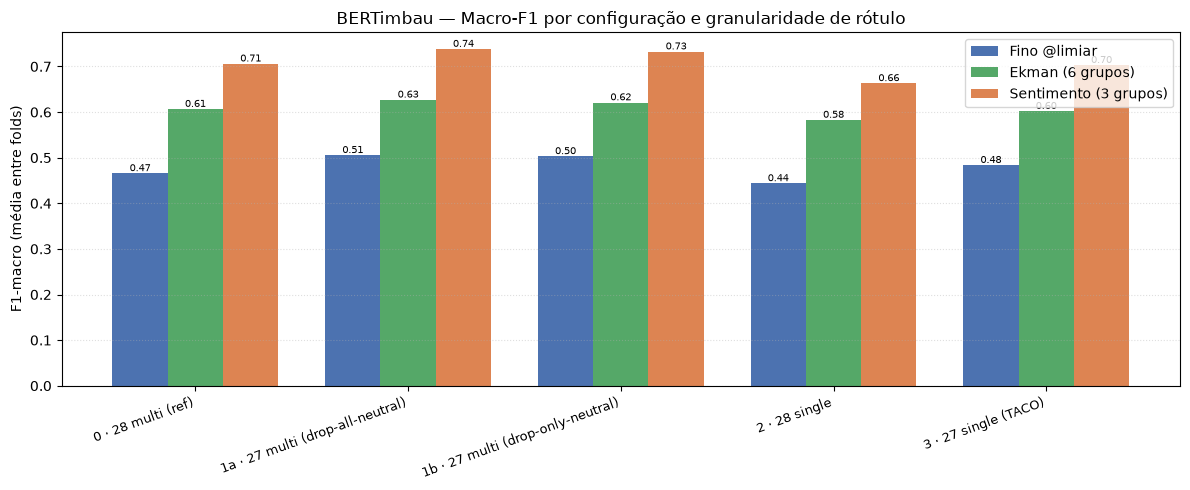

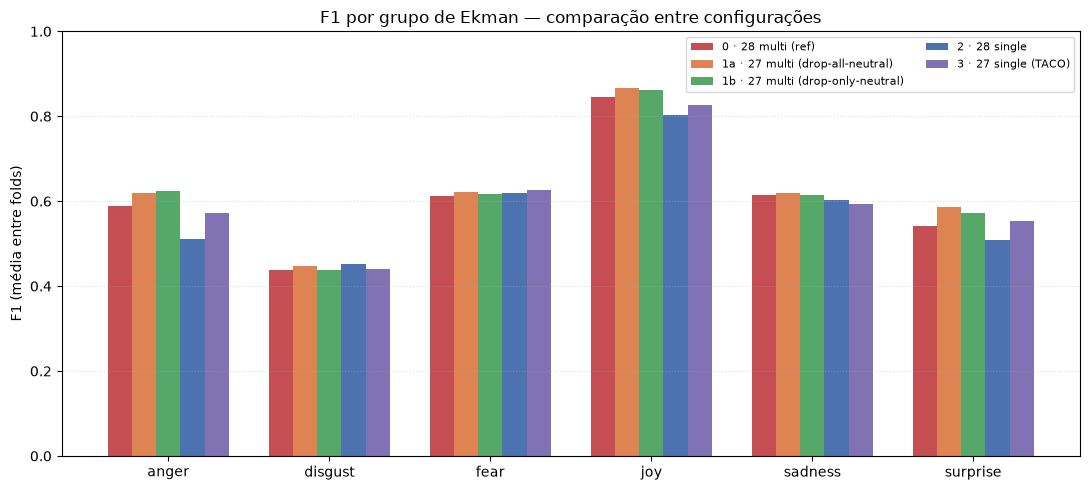

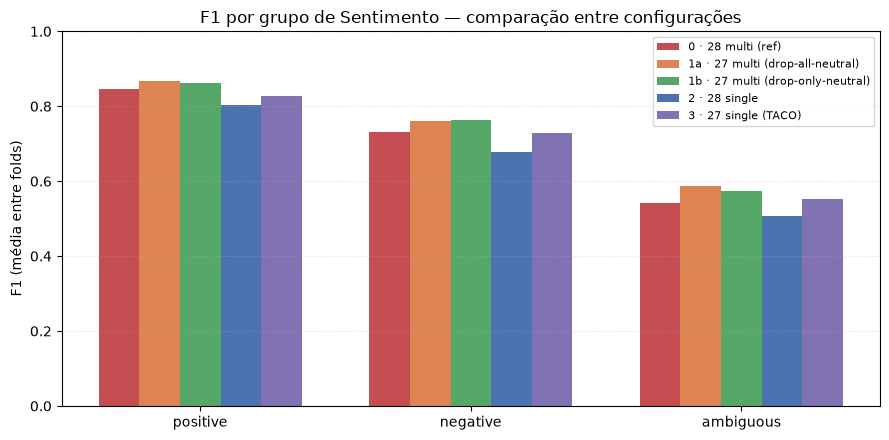

In [15]:
order = list(CONFIGS.keys())
disp  = [CONFIGS[k]["display"] for k in order]

fine   = [np.mean([m["f1_macro"] for m in config_fold_metrics[k]["tuned"]]) for k in order]
ekman  = [np.mean([m["macro"]    for m in grouped_fold[k]["ekman"]])         for k in order]
sentim = [np.mean([m["macro"]    for m in grouped_fold[k]["sentiment"]])     for k in order]

x = np.arange(len(order)); w = 0.26
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - w, fine,   w, label="Fino @limiar", color="#4C72B0")
ax.bar(x,     ekman,  w, label="Ekman (6 grupos)", color="#55A868")
ax.bar(x + w, sentim, w, label="Sentimento (3 grupos)", color="#DD8452")
ax.set_xticks(x); ax.set_xticklabels(disp, rotation=20, ha="right", fontsize=9)
ax.set_ylabel("F1-macro (média entre folds)")
ax.set_title("BERTimbau — Macro-F1 por configuração e granularidade de rótulo")
ax.legend(); ax.grid(axis="y", linestyle=":", alpha=0.4)
for xi, vals in zip(x, zip(fine, ekman, sentim)):
    for dx, v in zip((-w, 0, w), vals):
        ax.text(xi+dx, v+0.005, f"{v:.2f}", ha="center", fontsize=7)
plt.tight_layout(); plt.show()

# F1 por grupo de Ekman em cada config
ek_groups = list(EKMAN_MAP.keys())
ek_mat = np.array([[np.mean([m[g] for m in grouped_fold[k]["ekman"]]) for g in ek_groups] for k in order])
fig, ax = plt.subplots(figsize=(11, 5))
xg = np.arange(len(ek_groups)); wc = 0.15
colors = ["#C44E52", "#DD8452", "#55A868", "#4C72B0", "#8172B3"]
for i, k in enumerate(order):
    ax.bar(xg + (i-2)*wc, ek_mat[i], wc, label=CONFIGS[k]["display"], color=colors[i % len(colors)])
ax.set_xticks(xg); ax.set_xticklabels(ek_groups)
ax.set_ylabel("F1 (média entre folds)"); ax.set_ylim(0, 1)
ax.set_title("F1 por grupo de Ekman — comparação entre configurações")
ax.legend(fontsize=8, ncol=2); ax.grid(axis="y", linestyle=":", alpha=0.4)
plt.tight_layout(); plt.show()

# F1 por grupo de sentimento
se_groups = list(SENTIMENT_MAP.keys())
se_mat = np.array([[np.mean([m[g] for m in grouped_fold[k]["sentiment"]]) for g in se_groups] for k in order])
fig, ax = plt.subplots(figsize=(9, 4.5))
xs = np.arange(len(se_groups)); 
for i, k in enumerate(order):
    ax.bar(xs + (i-2)*wc, se_mat[i], wc, label=CONFIGS[k]["display"], color=colors[i % len(colors)])
ax.set_xticks(xs); ax.set_xticklabels(se_groups)
ax.set_ylabel("F1 (média entre folds)"); ax.set_ylim(0, 1)
ax.set_title("F1 por grupo de Sentimento — comparação entre configurações")
ax.legend(fontsize=8); ax.grid(axis="y", linestyle=":", alpha=0.4)
plt.tight_layout(); plt.show()

## F1 por emoção (por config) e exportação dos resultados

In [16]:
# F1 por emoção (@limiar) — união dos rótulos, NaN quando a emoção não existe na config
all_labels = EMOTION_COLS_28
per_emo = {}
for key, cfg in CONFIGS.items():
    s = pd.DataFrame([m["f1_per_label"] for m in config_fold_metrics[key]["tuned"]]).mean()
    per_emo[cfg["display"]] = s.reindex(all_labels)
df_per_emo = pd.DataFrame(per_emo)
df_per_emo = df_per_emo.loc[df_per_emo.mean(axis=1).sort_values(ascending=False).index]

print("===== F1 por emoção (@limiar, média entre folds) — NaN = rótulo ausente na config =====")
display(df_per_emo.round(3))

# ── exportação ──
EXPORT_DIR = OUT_BASE / "bert_configs_compare"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

# tabela global por fold (fino @0.5 e @limiar + agrupados)
rows_g = []
for key, cfg in CONFIGS.items():
    for k in range(1, N_OUTER_FOLDS+1):
        fx = config_fold_metrics[key]["fixed"][k-1]; tn = config_fold_metrics[key]["tuned"][k-1]
        ek = grouped_fold[key]["ekman"][k-1];        se = grouped_fold[key]["sentiment"][k-1]
        rows_g.append({
            "config": cfg["display"], "config_key": key, "outer_fold": k, "n_labels": cfg["n_labels"],
            "f1_macro_fixed": fx["f1_macro"], "f1_macro_tuned": tn["f1_macro"],
            "f1_micro_tuned": tn["f1_micro"], "precision_macro_tuned": tn["precision_macro"],
            "recall_macro_tuned": tn["recall_macro"], "roc_auc_macro": tn["roc_auc_macro"],
            "f1_macro_argmax": tn["f1_macro_argmax"],
            "ekman_macro": ek["macro"], "sentiment_macro": se["macro"],
        })
pd.DataFrame(rows_g).to_csv(EXPORT_DIR / "bert_configs_metrics_by_fold.csv", index=False)
df_final.to_csv(EXPORT_DIR / "bert_configs_summary.csv")
df_per_emo.to_csv(EXPORT_DIR / "bert_configs_f1_per_emotion.csv")

summary = {
    "modelo": MODEL_NAME,
    "pipeline": ("Mesmo do baseline_BERT: CV externa 5 folds, seleção de época por validação interna, "
                 "Class-Balanced BCE, sigmoid + limiar por emoção (@0.5 e @limiar)."),
    "configs": {key: {"display": c["display"], "n_labels": c["n_labels"], "mode": c["mode"]}
                for key, c in CONFIGS.items()},
    "taco_ref": ("Config 3 (27 single, sem neutral) = setup do TACO no GoEmotions "
                 "(single-label, 27 ids, neutral excluído)."),
    "agrupamentos": {"ekman_grupos": list(EKMAN_MAP.keys()),
                     "sentimento_grupos": list(SENTIMENT_MAP.keys()),
                     "nota": "neutral fora do agrupamento; avalia só instâncias com >=1 das 27 emoções."},
    "resultado_f1_macro_fino_tuned": {CONFIGS[k]["display"]:
        f"{np.mean([m['f1_macro'] for m in config_fold_metrics[k]['tuned']]):.4f}" for k in CONFIGS},
    "resultado_f1_macro_ekman": {CONFIGS[k]["display"]:
        f"{np.mean([m['macro'] for m in grouped_fold[k]['ekman']]):.4f}" for k in CONFIGS},
    "resultado_f1_macro_sentimento": {CONFIGS[k]["display"]:
        f"{np.mean([m['macro'] for m in grouped_fold[k]['sentiment']]):.4f}" for k in CONFIGS},
}
with open(EXPORT_DIR / "bert_configs_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

print("\nArquivos exportados para", EXPORT_DIR.resolve())
print(json.dumps(summary, indent=2, ensure_ascii=False))

===== F1 por emoção (@limiar, média entre folds) — NaN = rótulo ausente na config =====


,0 · 28 multi (ref),1a · 27 multi (drop-all-neutral),1b · 27 multi (drop-only-neutral),2 · 28 single,3 · 27 single (TACO)
gratitude,0.897,0.897,0.902,0.907,0.910
love,0.772,0.805,0.802,0.773,0.809
amusement,0.758,0.792,0.791,0.728,0.775
admiration,0.639,0.675,0.674,0.638,0.695
remorse,0.652,0.676,0.656,0.646,0.668
neutral,0.640,NaN,NaN,0.647,NaN
fear,0.566,0.616,0.601,0.589,0.630
optimism,0.543,0.577,0.557,0.582,0.594
desire,0.502,0.561,0.557,0.540,0.615
sadness,0.502,0.524,0.543,0.504,0.522



Arquivos exportados para C:\Users\redga\OneDrive\Área de Trabalho\UFJF\02 - TCC\tcc-emotion-detection-nlp\data\out\bert_configs_compare
{
  "modelo": "neuralmind/bert-base-portuguese-cased",
  "pipeline": "Mesmo do baseline_BERT: CV externa 5 folds, seleção de época por validação interna, Class-Balanced BCE, sigmoid + limiar por emoção (@0.5 e @limiar).",
  "configs": {
    "ref_28_multi": {
      "display": "0 · 28 multi (ref)",
      "n_labels": 28,
      "mode": "multi"
    },
    "27_multi_dropAll": {
      "display": "1a · 27 multi (drop-all-neutral)",
      "n_labels": 27,
      "mode": "multi"
    },
    "27_multi_dropOnly": {
      "display": "1b · 27 multi (drop-only-neutral)",
      "n_labels": 27,
      "mode": "multi"
    },
    "28_single": {
      "display": "2 · 28 single",
      "n_labels": 28,
      "mode": "single"
    },
    "27_single": {
      "display": "3 · 27 single (TACO)",
      "n_labels": 27,
      "mode": "single"
    }
  },
  "taco_ref": "Config 3 (27 sin